**1. IMPORT LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

**2. LOAD DATASET**

In [2]:
df = pd.read_csv("bigmart.csv")

**3. DATA EXPLORATION**

In [3]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [5]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [6]:
df.shape

(8523, 12)

In [7]:
df.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


In [8]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.nunique()

,0
Item_Identifier,1559
Item_Weight,415
Item_Fat_Content,5
Item_Visibility,7880
Item_Type,16
Item_MRP,5938
Outlet_Identifier,10
Outlet_Establishment_Year,9
Outlet_Size,3
Outlet_Location_Type,3


In [11]:
df.columns


Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

**4. FEATURE ENGINEERING**

In [12]:
df["Outlet_Age"] = 2026 - df["Outlet_Establishment_Year"]

In [13]:
#Check sales patterns
df[["Outlet_Establishment_Year","Outlet_Age"]].head()

,Outlet_Establishment_Year,Outlet_Age
0,1999,27
1,2009,17
2,1999,27
3,1998,28
4,1987,39


In [14]:
# Classify Fat content
df["Item_Fat_Content"] = df["Item_Fat_Content"].replace({
    "LF":"Low Fat",
    "low fat":"Low Fat",
    "reg":"Regular"
})

In [15]:
df["Item_Fat_Content"].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


In [16]:
# Classify item category
df["Item_Category"] = df["Item_Identifier"].str[:2]

In [17]:
df["Item_Category"] = df["Item_Category"].replace({
    "FD":"Food",
    "DR":"Drinks",
    "NC":"Non-Consumable"
})

In [18]:
df["Item_Category"].value_counts()

,count
Item_Category,
Food,6125
Non-Consumable,1599
Drinks,799


**5. DATA CLEANING & ENCODING**

In [19]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [20]:
df["Item_Weight"] = df["Item_Weight"].fillna(df["Item_Weight"].median())

In [21]:
df["Outlet_Size"] = df["Outlet_Size"].fillna(df["Outlet_Size"].mode()[0])

In [22]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [23]:
df = pd.get_dummies(
    df,
    drop_first=True
)

In [24]:
df.head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Outlet_Age,Item_Identifier_DRA24,Item_Identifier_DRA59,Item_Identifier_DRB01,Item_Identifier_DRB13,...,Outlet_Identifier_OUT049,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3,Item_Category_Food,Item_Category_Non-Consumable
0,9.30,0.016047,249.8092,1999,3735.1380,27,False,False,False,False,...,True,True,False,False,False,True,False,False,True,False
1,5.92,0.019278,48.2692,2009,443.4228,17,False,False,False,False,...,False,True,False,False,True,False,True,False,False,False
2,17.50,0.016760,141.6180,1999,2097.2700,27,False,False,False,False,...,True,True,False,False,False,True,False,False,True,False
3,19.20,0.000000,182.0950,1998,732.3800,28,False,False,False,False,...,False,True,False,False,True,False,False,False,True,False
4,8.93,0.000000,53.8614,1987,994.7052,39,False,False,False,False,...,False,False,False,False,True,True,False,False,False,True


**6. FEATURE SELECTION**

In [25]:
X = df.drop("Item_Outlet_Sales", axis=1)
y = df["Item_Outlet_Sales"]

In [26]:
print(X.shape)
print(y.shape)

(8523, 1597)
(8523,)


**7. TRAIN-TEST SPLIT**

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [28]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (6818, 1597)
Testing Features: (1705, 1597)
Training Target: (6818,)
Testing Target: (1705,)


**8. LINEAR REGRESSION**

In [29]:
lr = LinearRegression()

In [30]:
lr.fit(X_train, y_train)

LinearRegression()

In [31]:
#predictions
lr_predictions = lr.predict(X_test)

In [32]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": lr_predictions
})

comparison.head(10)

,Actual Sales,Predicted Sales
0,1743.0644,843.540035
1,356.8688,1032.112952
2,377.5086,1321.958010
3,5778.4782,3686.854033
4,2356.9320,1874.177354
5,865.5400,597.433082
6,4613.9940,4163.297419
7,2410.8618,2333.899518
8,1948.1308,1645.368055
9,1937.4780,3268.072167


**9. RANDOM FOREST REGRESSOR**

In [33]:
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [34]:
rf_predictions = rf.predict(X_test)

In [35]:
comparison_rf = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": rf_predictions
})

comparison_rf.head(10)

,Actual Sales,Predicted Sales
0,1743.0644,801.203746
1,356.8688,966.268882
2,377.5086,867.983486
3,5778.4782,4840.026442
4,2356.9320,2057.794718
5,865.5400,443.788990
6,4613.9940,5499.627844
7,2410.8618,1286.059280
8,1948.1308,1174.917286
9,1937.4780,2671.296128


**10. MODEL EVALUATION**

In [36]:
lr_mae = mean_absolute_error(y_test, lr_predictions)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))

lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Performance")
print("-----------------------------")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R²  :", lr_r2)

Linear Regression Performance
-----------------------------
MAE : 944.9370838999612
RMSE: 1274.2922925012504
R²  : 0.4025611736227126


In [37]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Performance")
print("-------------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Performance
-------------------------
MAE : 759.636891373607
RMSE: 1090.0349708534923
R²  : 0.5628442519374051


**11. FEATURE IMPORTANCE**

In [38]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": rf.feature_importances_

})

In [39]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [40]:
feature_importance.head(10)

,Feature,Importance
2,Item_MRP,0.397883
1592,Outlet_Type_Supermarket Type1,0.095824
1583,Outlet_Identifier_OUT027,0.059570
1,Item_Visibility,0.057423
1594,Outlet_Type_Supermarket Type3,0.047930
3,Outlet_Establishment_Year,0.034353
0,Item_Weight,0.029828
4,Outlet_Age,0.021614
1593,Outlet_Type_Supermarket Type2,0.013621
1581,Outlet_Identifier_OUT018,0.011276


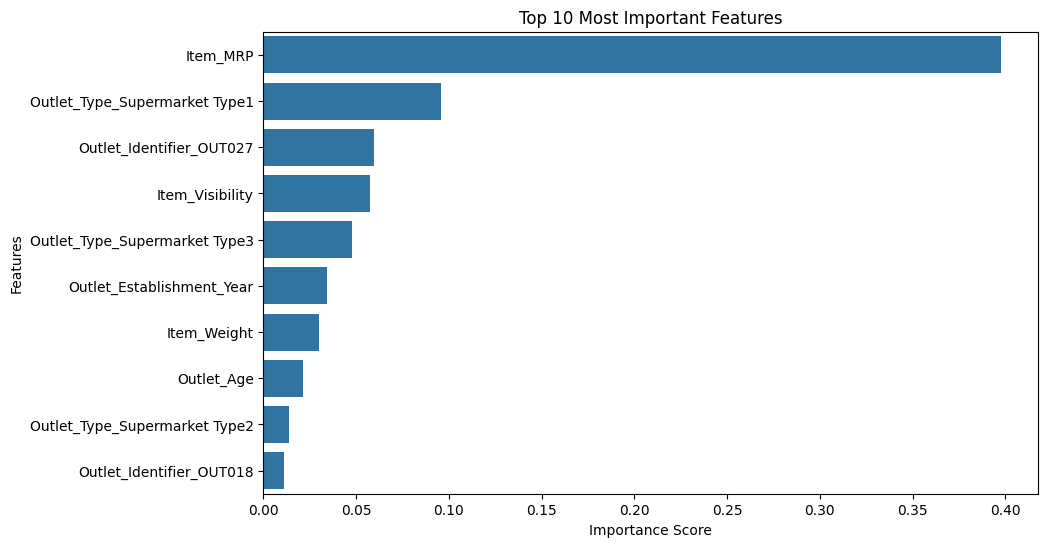

In [41]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

**12. ACTUAL VS PREDICTED VALUES**

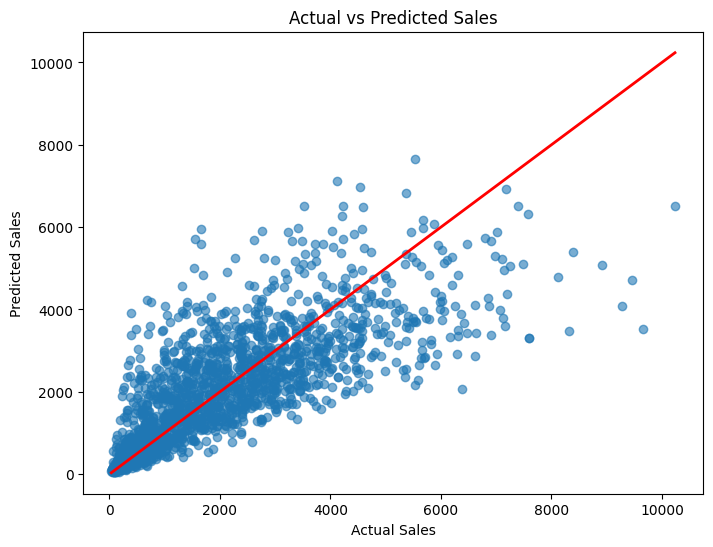

In [42]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.6
)

plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    color="red",

    linewidth=2

)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

**13. HYPERPARAMETER TUNING**

In [43]:
param_grid = {

    "n_estimators": [100, 200],

    "max_depth": [10, 20, None],

    "min_samples_split": [2, 5]

}

In [44]:
grid_search = GridSearchCV(

    estimator=RandomForestRegressor(random_state=42),

    param_grid=param_grid,

    cv=3,

    scoring="r2",

    n_jobs=-1

)

In [45]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2')

In [46]:
print("Best Parameters:")

grid_search.best_params_

Best Parameters:


{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}

In [47]:
best_rf = grid_search.best_estimator_

In [48]:
best_predictions = best_rf.predict(X_test)

In [49]:
best_mae = mean_absolute_error(y_test, best_predictions)

best_rmse = np.sqrt(mean_squared_error(y_test, best_predictions))

best_r2 = r2_score(y_test, best_predictions)

print("Optimized Random Forest")

print("-----------------------")

print("MAE :", best_mae)

print("RMSE:", best_rmse)

print("R²  :", best_r2)

Optimized Random Forest
-----------------------
MAE : 720.1417193458384
RMSE: 1031.3095994149753
R²  : 0.6086787331070846


**14. MODEL PERFORMANCE**

In [50]:
summary = pd.DataFrame({

    "Model":[

        "Linear Regression",

        "Random Forest",

        "Optimized Random Forest"

    ],

    "MAE":[

        lr_mae,

        rf_mae,

        best_mae

    ],

    "RMSE":[

        lr_rmse,

        rf_rmse,

        best_rmse

    ],

    "R² Score":[

        lr_r2,

        rf_r2,

        best_r2

    ]

})

summary

,Model,MAE,RMSE,R² Score
0,Linear Regression,944.937084,1274.292293,0.402561
1,Random Forest,759.636891,1090.034971,0.562844
2,Optimized Random Forest,720.141719,1031.309599,0.608679


**15. BUSINESS INTERPRETATION**

**1.** The Random Forest model achieved better prediction performance than the Linear Regression model, indicating that product sales are influenced by complex relationships among the input features.

**2.** The feature importance analysis suggests that variables such as product price, outlet characteristics, and product attributes play significant roles in determining sales.


**3.** This predictive model can assist retailers in inventory planning, pricing strategies, and sales forecasting, leading to more informed business decisions.

**16. CONCLUSION**

A complete machine learning pipeline was successfully implemented using the BigMart Sales dataset.

The project included data exploration, feature engineering, preprocessing, model training, evaluation, feature importance analysis, visualization, and hyperparameter tuning.

Among the models tested, the Random Forest Regressor provided superior predictive performance compared to the Linear Regression model. The optimized Random Forest model further improved prediction accuracy after hyperparameter tuning.

Overall, the developed model provides a reliable approach for predicting product sales and can support business decision-making in areas such as inventory management, pricing optimization, and demand forecasting.